<a href="https://colab.research.google.com/github/BernardoBremer/Inteligencia-Computacional-Cetys-/blob/main/FeedForward.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Neural Networks (implementacion con pytorch)

usando el notebook de introduction to neural networks como base, ahora se realizara utilizando pytorch, torch, nn.linear y nn.ReLU, en este ejercicio se entrenan 3 networks distintas con arquitectura variada  como learning rate, batch size, epochs y al final se evaluara el mejor modelo en el conjusto de test

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

## MNIST dataset (carga como dataset de pytorch)

los arrays de numpy ya estan cargados y normalizados en el notebook original, simplemente los convertimos a tensores y los envolvemos en Tensordataset

In [25]:
X_train_t = torch.tensor(x_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.squeeze(), dtype=torch.long)

X_val_t = torch.tensor(x_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val.squeeze(), dtype=torch.long)

X_test_t = torch.tensor(x_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test.squeeze(), dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t,   y_val_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

print(f"Tamaño de entrenamiento: {len(train_dataset)}")
print(f"Tamaño de validación:    {len(val_dataset)}")
print(f"Tamaño de test:          {len(test_dataset)}")

Tamaño de entrenamiento: 50000
Tamaño de validación:    10000
Tamaño de test:          10000


### Definición de las 3 Redes Neuronales

Se definen 3 arquitecturas diferentes usando únicamente nn.Linear y nn.ReLU:

| Modelo | Arquitectura | LR | Batch Size | Épocas |
|--------|-------------|-----|------------|--------|
| Modelo A | 784 → 128 → 10 | 0.001 | 64 | 15 |
| Modelo B | 784 → 256 → 128 → 10 | 0.0005 | 128 | 20 |
| Modelo C | 784 → 512 → 256 → 128 → 10 | 0.0003 | 32 | 15 |

In [44]:
class ModeloA(nn.Module):
    def __init__(self):
        super(ModeloA, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.red(x)


class ModeloB(nn.Module):
    def __init__(self):
        super(ModeloB, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.red(x)


class ModeloC(nn.Module):
    def __init__(self):
        super(ModeloC, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.red(x)

#Funcion de loss y entrenamiento



In [45]:
def entrenar_modelo(modelo, train_dataset, val_dataset, epochs, batch_size, learning_rate):
    modelo = modelo.to(device)
    criterio = nn.CrossEntropyLoss()
    optimizador = optim.Adam(modelo.parameters(), lr=learning_rate)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

    historial = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoca in range(epochs):
        modelo.train()
        total_loss, correctos, total = 0.0, 0, 0

        barra = tqdm(train_loader, desc=f"Época {epoca+1}/{epochs}", leave=True)
        for imagenes, etiquetas in barra:
            imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
            salidas = modelo(imagenes)
            loss = criterio(salidas, etiquetas)
            optimizador.zero_grad()
            loss.backward()
            optimizador.step()

            total_loss += loss.item() * imagenes.size(0)
            _, predicciones = torch.max(salidas, 1)
            correctos += (predicciones == etiquetas).sum().item()
            total += etiquetas.size(0)
            barra.set_postfix(loss=f"{loss.item():.4f}")

        train_loss = total_loss / total
        train_acc = correctos / total

        modelo.eval()
        val_loss_total, val_correctos, val_total = 0.0, 0, 0

        with torch.no_grad():
            for imagenes, etiquetas in val_loader:
                imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
                salidas = modelo(imagenes)
                loss = criterio(salidas, etiquetas)
                val_loss_total += loss.item() * imagenes.size(0)
                _, predicciones = torch.max(salidas, 1)
                val_correctos += (predicciones == etiquetas).sum().item()
                val_total += etiquetas.size(0)

        val_loss = val_loss_total / val_total
        val_acc = val_correctos / val_total

        historial['train_loss'].append(train_loss)
        historial['train_acc'].append(train_acc)
        historial['val_loss'].append(val_loss)
        historial['val_acc'].append(val_acc)

        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return historial


def evaluar_en_test(modelo, test_dataset):
    modelo.eval()
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)
    criterio = nn.CrossEntropyLoss()
    test_loss_total, correctos, total = 0.0, 0, 0

    with torch.no_grad():
        for imagenes, etiquetas in test_loader:
            imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
            salidas = modelo(imagenes)
            loss = criterio(salidas, etiquetas)
            test_loss_total += loss.item() * imagenes.size(0)
            _, predicciones = torch.max(salidas, 1)
            correctos += (predicciones == etiquetas).sum().item()
            total += etiquetas.size(0)

    return test_loss_total / total, correctos / total


print("funciones definidas.")

Funciones definidas.


In [27]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.reshape((28,28)), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

Every time you run this cell, a random number from the training set will be displayed. You can run it multiple times to see different images from the dataset.

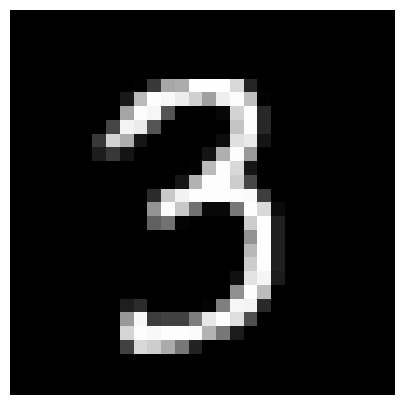

'Label: 3'

In [28]:
random_idx = np.random.randint(0, x_train.shape[0])
plot_number(x_train[random_idx])
display(f"Label: {y_train[random_idx].squeeze()}")

## Defining the Neural Network

In [29]:
# This custom subclass will allow us to store the parameters and gradients of each layer without losing the original numpy functionality.
class Tensor(np.ndarray):
    grad = None # Will be initialized during backpropagation

In [30]:
class LinearLayer():
    def __init__(self, input_size, output_size):
        '''
        Init parameters using Kaiming initialization
        '''
        self.W = (np.random.randn(output_size, input_size) * np.sqrt(2/input_size)).view(Tensor)
        self.b = (np.zeros((output_size, 1))).view(Tensor)


    def forward(self, X):
        Z = self.W @ X + self.b
        return Z

    def backward(self, X, Z):
        X.grad = self.W.T @ Z.grad
        self.W.grad = Z.grad @ X.T
        self.b.grad = np.sum(Z.grad, axis = 1, keepdims=True)




In [31]:
class ReLU:
    def forward(self, Z):
        return np.maximum(0, Z)
    def backward(self, Z, A):
        Z.grad = A.grad.copy()
        Z.grad[Z <= 0] = 0

In [32]:
class NeuralNetwork:
    def __init__(self, layers):
        self.layers = layers
        self.x = None
        self.outputs = {}

    def forward(self, X):
        self.x = X
        self.outputs[0] = self.x
        for i, layer in enumerate(self.layers, 1):
            self.x = layer.forward(self.x)
            self.outputs[i]=self.x
        return self.x

    def backward(self):
        for i in reversed(range(len(self.layers))):
            self.layers[i].backward(self.outputs[i], self.outputs[i+1])

    def update(self, learning_rate = 1e-3):
        for layer in self.layers:
            if isinstance(layer, ReLU): continue
            layer.W = layer.W - learning_rate * layer.W.grad
            layer.b = layer.b - learning_rate * layer.b.grad

## Training the Neural Network

Let's apply standard scaling to the input data. Since we are not using sklearn, we will implement it ourselves. We will calculate the mean and standard deviation of the training data, and then use those values to scale the training, validation, and test sets.

In [33]:
def scale(x_mean, x_std, x_data):
    return (x_data - x_mean) / x_std

x_mean = x_train.mean()
x_std = x_train.std()

x_train = scale(x_mean, x_std, x_train)
x_val = scale(x_mean, x_std, x_val)
x_test = scale(x_mean, x_std, x_test)

When training a neural network, it is common to use mini-batch gradient descent. This means that instead of updating the weights after every single training example, we will update them after a small batch of examples. This can help to stabilize the training process and can also speed up convergence. The following function will create mini-batches from the training data.

In [34]:
def create_minibatches(batch_size, x, y, shuffle = False):
    total_data = x.shape[0]
    if shuffle:
        idxs = np.arange(total_data)
        np.random.shuffle(idxs)
        x = x[idxs]
        y = y[idxs]
    return ((x[i:i + batch_size], y[i:i + batch_size]) for i in range(0, total_data, batch_size))

We also need to define our loss function. For multi-class classification, a common choice is the softmax cross-entropy loss. This loss function combines the softmax activation function with the cross-entropy loss, which measures the difference between the predicted probabilities and the true labels. The following function will compute the softmax cross-entropy loss and also calculate the gradients needed for backpropagation.

In [35]:
def softmaxXEntropy(x, y):
    batch_size = x.shape[1]
    exp_scores = np.exp(x)
    probs = exp_scores / exp_scores.sum(axis = 0)

    # Cost
    y_hat = probs[y.squeeze(), np.arange(batch_size)]
    cost = np.sum(-np.log(y_hat)) / batch_size

    # Gradients
    # For a softmax layer, the gradient is just the predicted probabilities minus the one-hot encoded true labels.
    probs[y.squeeze(), np.arange(batch_size)] -= 1
    x.grad = probs.copy()

    return cost


Let's also create the accuracy function to measure the performance of our model on the validation set during training.

In [36]:
def accuracy(x, y):
    pred = model.forward(x.T.view(Tensor))
    correct = np.sum(np.argmax(pred, axis=0) == y.squeeze())
    total = pred.shape[1]
    return correct/total

Let's now define the training loop for our neural network. In each epoch, we will iterate over the mini-batches of the training data, perform a forward pass to compute the predictions, calculate the loss and gradients using the softmax cross-entropy function, perform a backward pass to compute the gradients for each layer, and then update the weights using gradient descent. After each epoch, we will also evaluate the accuracy on the validation set.

In [37]:
def train(model, epochs, batch_size=128, learning_rate=1e-3):
    for epoch in range(epochs):
        epoch_iterator = tqdm(
            enumerate(create_minibatches(batch_size, x_train, y_train)),
            total=len(x_train) // batch_size,
            desc=f"Epoch {epoch+1}/{epochs}",
            leave=True
        )

        for i, (x, y) in epoch_iterator:
            scores = model.forward(x.T.view(Tensor))
            cost = softmaxXEntropy(scores, y)
            model.backward()
            model.update(learning_rate)

            epoch_iterator.set_postfix(cost=f"{cost:.4f}")

        val_acc = accuracy(x_val, y_val)
        print(f"Cost: {cost:.4f}, Val Accuracy: {val_acc:.4f}")


Let's now define our neural network architecture. It has three layers:
- Input layer with 784 neurons (one for each pixel in the input image)
- Hidden layer with 200 neurons and ReLU activation
- Output layer with 10 neurons (one for each class) and no activation function (since we will apply the softmax function in the loss function)

In [38]:
model = NeuralNetwork([
    LinearLayer(784, 200),
    ReLU(),
    LinearLayer(200, 10)])

Set up our training parameters and start training the model.

In [39]:
print(f"accuracy before training: {accuracy(x_val, y_val)}")

accuracy before training: 0.1668


In [40]:
mb_size = 256
learning_rate = 0.0001
epochs = 20
train(model, epochs, mb_size, learning_rate)

Epoch 1/20: 196it [00:04, 41.78it/s, cost=0.4657]                         


Cost: 0.4657, Val Accuracy: 0.9125


Epoch 2/20: 196it [00:03, 50.24it/s, cost=0.3582]                         


Cost: 0.3582, Val Accuracy: 0.9295


Epoch 3/20: 196it [00:03, 60.16it/s, cost=0.3005]                         


...

Cost: 0.0877, Val Accuracy: 0.9688


Epoch 19/20: 196it [00:05, 35.03it/s, cost=0.0826]                         


Cost: 0.0826, Val Accuracy: 0.9694


Epoch 20/20: 196it [00:03, 59.71it/s, cost=0.0779]                         


Cost: 0.0779, Val Accuracy: 0.9701


## Testing the model

With the model trained, we can now evaluate its performance on the test set. We will use the same accuracy function that we defined earlier to measure the accuracy of the model on the test set.

In [41]:
print(f'Test accuracy: {accuracy(x_test, y_test)}')

Test accuracy: 0.968


We can also visualize the confusion matrix.

Text(0.5, 1.0, 'Confusion Matrix')

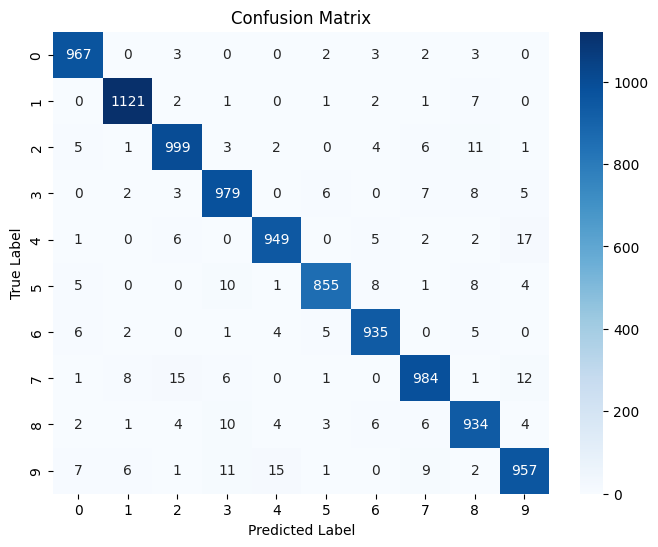

In [42]:
test_scores = model.forward(x_test.T.view(Tensor))
y_pred = np.argmax(test_scores, axis=0)
conf_matrix = np.zeros((10, 10), dtype=int)

for true_label, pred_label in zip(y_test.squeeze(), y_pred.squeeze()):
    conf_matrix[true_label, pred_label] += 1

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[str(i) for i in range(10)], yticklabels=[str(i) for i in range(10)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

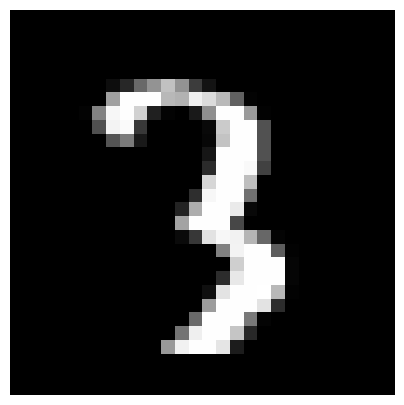

'Label: 3'

'Predicted: 3'

In [43]:
random_idx = np.random.randint(0, x_test.shape[0])
plot_number(x_test[random_idx])
display(f"Label: {y_test[random_idx].squeeze()}", f"Predicted: {y_pred[random_idx]}")